In [3]:
ls

auto_df_100ms_1core.csv   auto_df_1s_1core.csv      auto_df_50ms_1core.csv
auto_df_100ms.csv         auto_df_1s.csv            auto_df_50ms.csv
auto_df_100ms_hybrid.csv  auto_df_1s_hybrid.csv     auto_df_50ms_hybrid.csv
auto_df_10ms_1core.csv    auto_df_200ms_1core.csv   Untitled3.ipynb
auto_df_10ms.csv          auto_df_200ms.csv
auto_df_10ms_hybrid.csv   auto_df_200ms_hybrid.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 5420 samples, median=7.2ms, p99=426.7ms
  [OK]   Hybrid / 10ms — 4584 samples, median=10.7ms, p99=71.9ms
  [OK]   Local 1core / 10ms — 4999 samples, median=6.4ms, p99=542.3ms
  [OK]   Local / 50ms — 2253 samples, median=16.5ms, p99=250.3ms
  [OK]   Hybrid / 50ms — 1808 samples, median=13.1ms, p99=51.5ms
  [OK]   Local 1core / 50ms — 1982 samples, median=17.7ms, p99=219.4ms
  [OK]   Local / 100ms — 1569 samples, median=17.3ms, p99=195.3ms
  [OK]   Hybrid / 100ms — 1870 samples, median=13.2ms, p99=65.5ms
  [OK]   Local 1core / 100ms — 1902 samples, median=13.7ms, p99=217.5ms
  [OK]   Local / 200ms — 1523 samples, median=13.0ms, p99=191.1ms
  [OK]   Hybrid / 200ms — 1782 samples, median=12.6ms, p99=50.9ms
  [OK]   Local 1core / 200ms — 1749 samples, median=12.8ms, p99=221.9ms
  [OK]   Local / 1s — 2599 samples, median=9.1ms, p99=158.2ms
  [OK]   Hybrid / 1s — 2775 samples, median=13.1ms, p99=51.1ms
  [OK]  

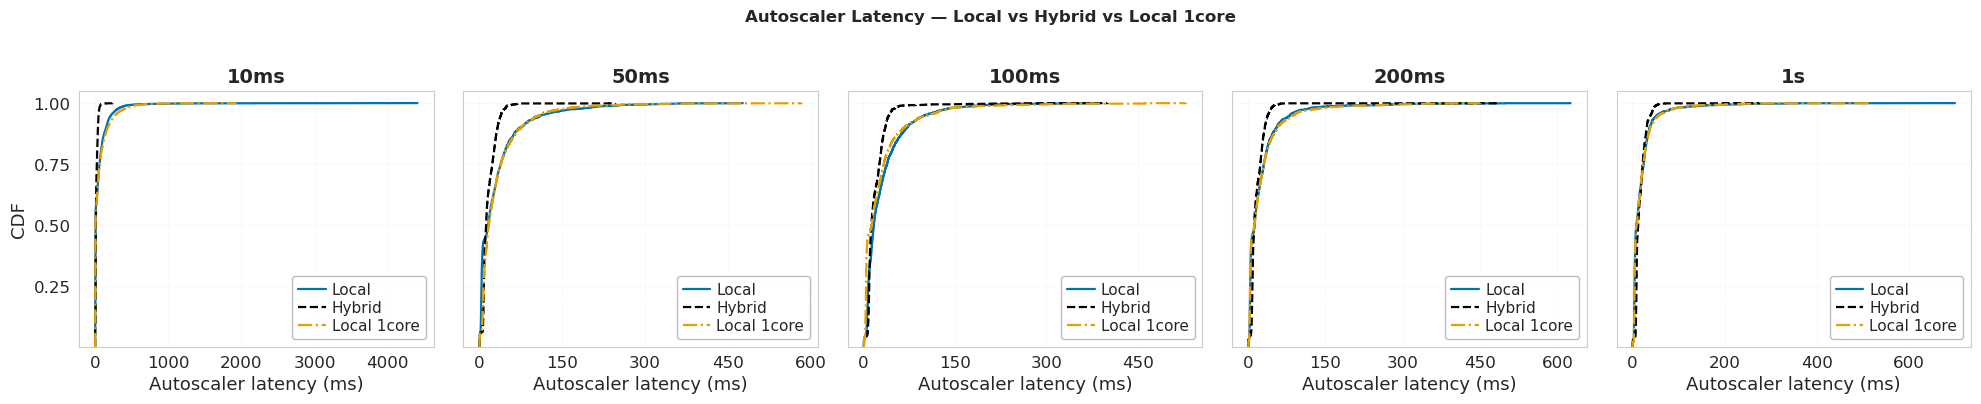

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"auto_df_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"auto_df_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"auto_df_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["reconcile_time_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Autoscaler latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Autoscaler Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "auto_ecdf_overlay.pdf"
out_png = "auto_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")